#Libraries

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# for mode operation
from statistics import mode
# scaling numerical data
from sklearn.preprocessing import MinMaxScaler
# encoding non numerical columns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# Mutual information library
from sklearn.feature_selection import mutual_info_regression
# for train test split we have to import the method from scikit learn
from sklearn.model_selection import train_test_split

#Read Data

In [55]:
filepath = '/content/drive/MyDrive/AI ML/Datasets/House_Pricing.csv'
df_house = pd.read_csv(filepath)
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


#EDA

In [56]:
df_house.shape

(21613, 21)

In [57]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [58]:
df_house.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [59]:
df_house.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [60]:
df_house = df_house.drop(columns = ['No of Times Visited'], axis = 1)    # No of Times Visited column contains big number of missing vales.

In [61]:
df_house.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


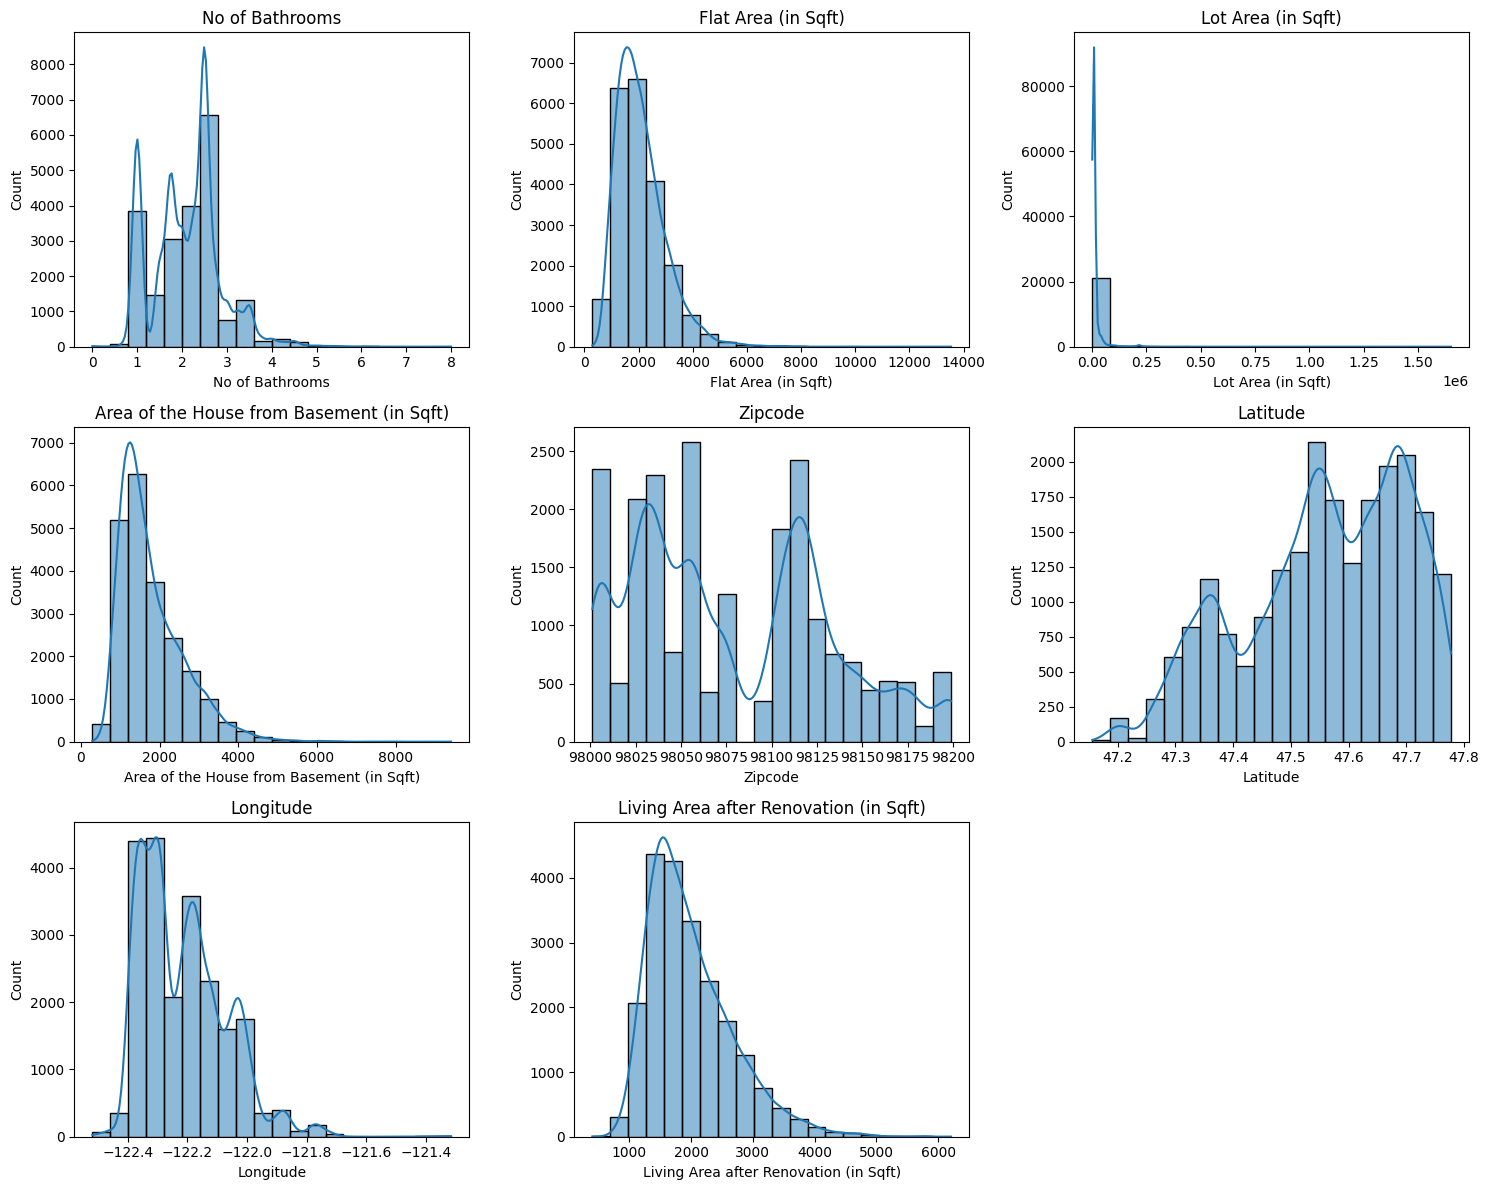

In [62]:
# Histogram plottings for null value handling

missing_cols = ['No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Area of the House from Basement (in Sqft)', 'Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)' ]

plt.figure(figsize = (15,12))
for i, col in enumerate(missing_cols, 1):
  plt.subplot(3,3,i)
  sns.histplot(df_house[col], bins=20, kde = True)
  plt.title(col)
plt.tight_layout()
plt.show()


# Duplicate Handling

In [63]:
df_house.duplicated().sum()

np.int64(0)

#Missing Value Handling

In [64]:
# As SalePrice is the target value, we need to drop the missing value rows.

# Before dropping rows
df_house.isnull().sum()



,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [65]:
# Drop the rows
df_house = df_house.dropna(subset=['Sale Price', 'Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)'])

# After dropping rows
df_house.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [66]:
df_house.shape

(21605, 20)

In [67]:
# Filling the missing value

df_house['No of Bathrooms'].fillna(mode(df_house['No of Bathrooms']), inplace=True)
df_house['Flat Area (in Sqft)'].fillna(df_house['Flat Area (in Sqft)'].median(), inplace = True)
df_house['Lot Area (in Sqft)'].fillna(df_house['Lot Area (in Sqft)'].median(), inplace = True)
df_house['Area of the House from Basement (in Sqft)'].fillna(df_house['Area of the House from Basement (in Sqft)'].median(), inplace = True)

/tmp/ipykernel_1901/1109648162.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['No of Bathrooms'].fillna(mode(df_house['No of Bathrooms']), inplace=True)
/tmp/ipykernel_1901/1109648162.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [68]:
# After handling missing values
df_house.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


#Fixing Target and Features

In [69]:
y = df_house['Sale Price']  # Here Sale Price is set as target column.

X = df_house.drop('Sale Price', axis = 1)     # X contains all features except the target column.

# Feature Engineering

In [70]:
num_cols = X.select_dtypes(include=['int64','float64']).columns    # Fetching numerical columns of feature
cat_cols = X.select_dtypes(include=['object']).columns             # Fetching categorical columns of feature

print(num_cols)
print(cat_cols)

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


In [71]:
X.nunique()

,0
ID,21428
Date House was Sold,13
No of Bedrooms,13
No of Bathrooms,30
Flat Area (in Sqft),1036
Lot Area (in Sqft),9777
No of Floors,6
Waterfront View,2
Condition of the House,5
Overall Grade,10


# Split date column for encoding

In [72]:
# We cannot drectly encode date values, we need to split it to date,month and year.
# Convert date
df_house['Date House was Sold'] = pd.to_datetime(df_house['Date House was Sold'], dayfirst = True)

# Extract year and month
df_house['sale_year'] = df_house['Date House was Sold'].dt.year
df_house['sale_month'] = df_house['Date House was Sold'].dt.month_name()
df_house['sale_day'] = df_house['Date House was Sold'].dt.day

X['sale_year'] = df_house['sale_year']
X['sale_month'] = df_house['sale_month']
X['sale_day'] = df_house['sale_day']

In [73]:
# Drop the date column

X.drop('Date House was Sold', axis = 1, inplace = True)

# Scaling Numerical Columns

In [74]:
X.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_year,sale_month,sale_day
0,7129300520,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,October,14
1,6414100192,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,December,14
2,5631500400,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,February,15
3,2487200875,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,...,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,December,14
4,1954400510,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,...,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,February,15


In [75]:
# Scaling the numerical columns of the feature column as it all are skewed we can use normalization ( MinMax Scaling )

min_max_scaler = MinMaxScaler()
skewed_cols = ['sale_year', 'sale_day', 'Flat Area (in Sqft)',	'Lot Area (in Sqft)',	'Area of the House from Basement (in Sqft)',	'Basement Area (in Sqft)',	'Age of House (in Years)',	'Renovated Year',	'Latitude',	'Longitude',	'Living Area after Renovation (in Sqft)',	'Lot Area after Renovation (in Sqft)']

X[skewed_cols] = min_max_scaler.fit_transform(X[skewed_cols])

#Encoding

In [76]:
print(cat_cols)

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


In [77]:
X['sale_month'].unique()

array(['October', 'December', 'February', 'May', 'June', 'January',
       'April', 'March', 'July', 'August', 'November', 'September'],
      dtype=object)

In [78]:
X['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [79]:
X['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

##Label Encoding

In [80]:
# Before encoding
X.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_year,sale_month,sale_day
0,7129300520,3,1.00,0.067170,0.003108,1.0,No,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,1.0,October,0.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,No,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,1.0,December,0.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,No,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,0.0,February,1.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,No,Excellent,7,0.083333,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,1.0,December,0.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,No,Fair,8,0.152412,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,0.0,February,1.0


In [81]:
# we use label encoding on waterfrontview column because it has only binary categories.
label_encoder = LabelEncoder()
X['Waterfront View'] = label_encoder.fit_transform(X['Waterfront View'])

In [82]:
# After encoding
X.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_year,sale_month,sale_day
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,1.0,October,0.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,1.0,December,0.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,0.0,February,1.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,Excellent,7,0.083333,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,1.0,December,0.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,Fair,8,0.152412,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,0.0,February,1.0


##OneHotEncoding

In [83]:
# Before encoding
X.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_year,sale_month,sale_day
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,1.0,October,0.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,1.0,December,0.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,0.0,February,1.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,Excellent,7,0.083333,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,1.0,December,0.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,Fair,8,0.152412,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,0.0,February,1.0


In [84]:
#OneHotEncoder is used because the column needs encoding is categorical and they are features.

OHE_obj = OneHotEncoder(sparse_output = False)
ohe_cols = ['Condition of the House', 'sale_month']

encoded_data = OHE_obj.fit_transform(X[ohe_cols])
encoded_cols = OHE_obj.get_feature_names_out(ohe_cols)

encoded_X = pd.DataFrame(encoded_data, columns = encoded_cols, index = X.index)
encoded_X.head(3)


,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay,sale_month_April,sale_month_August,sale_month_December,sale_month_February,sale_month_January,sale_month_July,sale_month_June,sale_month_March,sale_month_May,sale_month_November,sale_month_October,sale_month_September
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [85]:
X = pd.concat([X.drop(columns = ohe_cols), encoded_X], axis = 1)    # Combines the encoded columns with X
X.head(10)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,sale_month_December,sale_month_February,sale_month_January,sale_month_July,sale_month_June,sale_month_March,sale_month_May,sale_month_November,sale_month_October,sale_month_September
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,7,0.097588,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,7,0.206140,0.082988,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,6,0.052632,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,7,0.083333,0.188797,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,8,0.152412,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,7237550310,4,4.50,0.387170,0.061429,1.0,0,10,0.394737,0.317427,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,1321400060,3,2.25,0.107547,0.003816,2.0,0,7,0.156250,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,2008000270,3,1.50,0.058113,0.005567,1.0,0,7,0.084430,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2414600126,3,1.00,0.112453,0.004210,1.0,0,7,0.083333,0.151452,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,3793500160,3,2.50,0.120755,0.003659,2.0,0,7,0.175439,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [86]:
# Before encoding
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21605 entries, 0 to 21612
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21605 non-null  int64  
 1   No of Bedrooms                             21605 non-null  int64  
 2   No of Bathrooms                            21605 non-null  float64
 3   Flat Area (in Sqft)                        21605 non-null  float64
 4   Lot Area (in Sqft)                         21605 non-null  float64
 5   No of Floors                               21605 non-null  float64
 6   Waterfront View                            21605 non-null  int64  
 7   Overall Grade                              21605 non-null  int64  
 8   Area of the House from Basement (in Sqft)  21605 non-null  float64
 9   Basement Area (in Sqft)                    21605 non-null  float64
 10  Age of House (in Years)    

# Mutual Information

In [87]:
mi = mutual_info_regression(X, y)   # mutual_info_regression is used because target varialble is continuous values.
mi_X = pd.DataFrame({'Features' : X.columns, 'Mutual Information' : mi})
mi_X

,Features,Mutual Information
0,ID,0.109372
1,No of Bedrooms,0.080773
2,No of Bathrooms,0.202892
3,Flat Area (in Sqft),0.349140
4,Lot Area (in Sqft),0.059497
5,No of Floors,0.079997
6,Waterfront View,0.013029
7,Overall Grade,0.351530
8,Area of the House from Basement (in Sqft),0.263489
9,Basement Area (in Sqft),0.071919


In [88]:
selected_features = mi_X[mi_X['Mutual Information'] > 0.01]   # Threshold value is set as 0.01 to find the strong relationship columns to target.
selected_features

,Features,Mutual Information
0,ID,0.109372
1,No of Bedrooms,0.080773
2,No of Bathrooms,0.202892
3,Flat Area (in Sqft),0.349140
4,Lot Area (in Sqft),0.059497
5,No of Floors,0.079997
6,Waterfront View,0.013029
7,Overall Grade,0.351530
8,Area of the House from Basement (in Sqft),0.263489
9,Basement Area (in Sqft),0.071919


In [89]:
# We need only the selected features above 0.01 value as it has stronger relationship with the Sale Price.

X = X[selected_features['Features'].tolist()]
X.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_month_January,sale_month_June
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,7,0.097588,0.000000,0.521739,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,0.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,7,0.206140,0.082988,0.556522,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,0.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,6,0.052632,0.000000,0.713043,98028.0,0.936143,0.237542,0.399415,0.008513,0.0,0.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,7,0.083333,0.188797,0.434783,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,0.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,8,0.152412,0.000000,0.243478,98074.0,0.741354,0.393688,0.241094,0.007871,0.0,0.0


#Outlier Handling

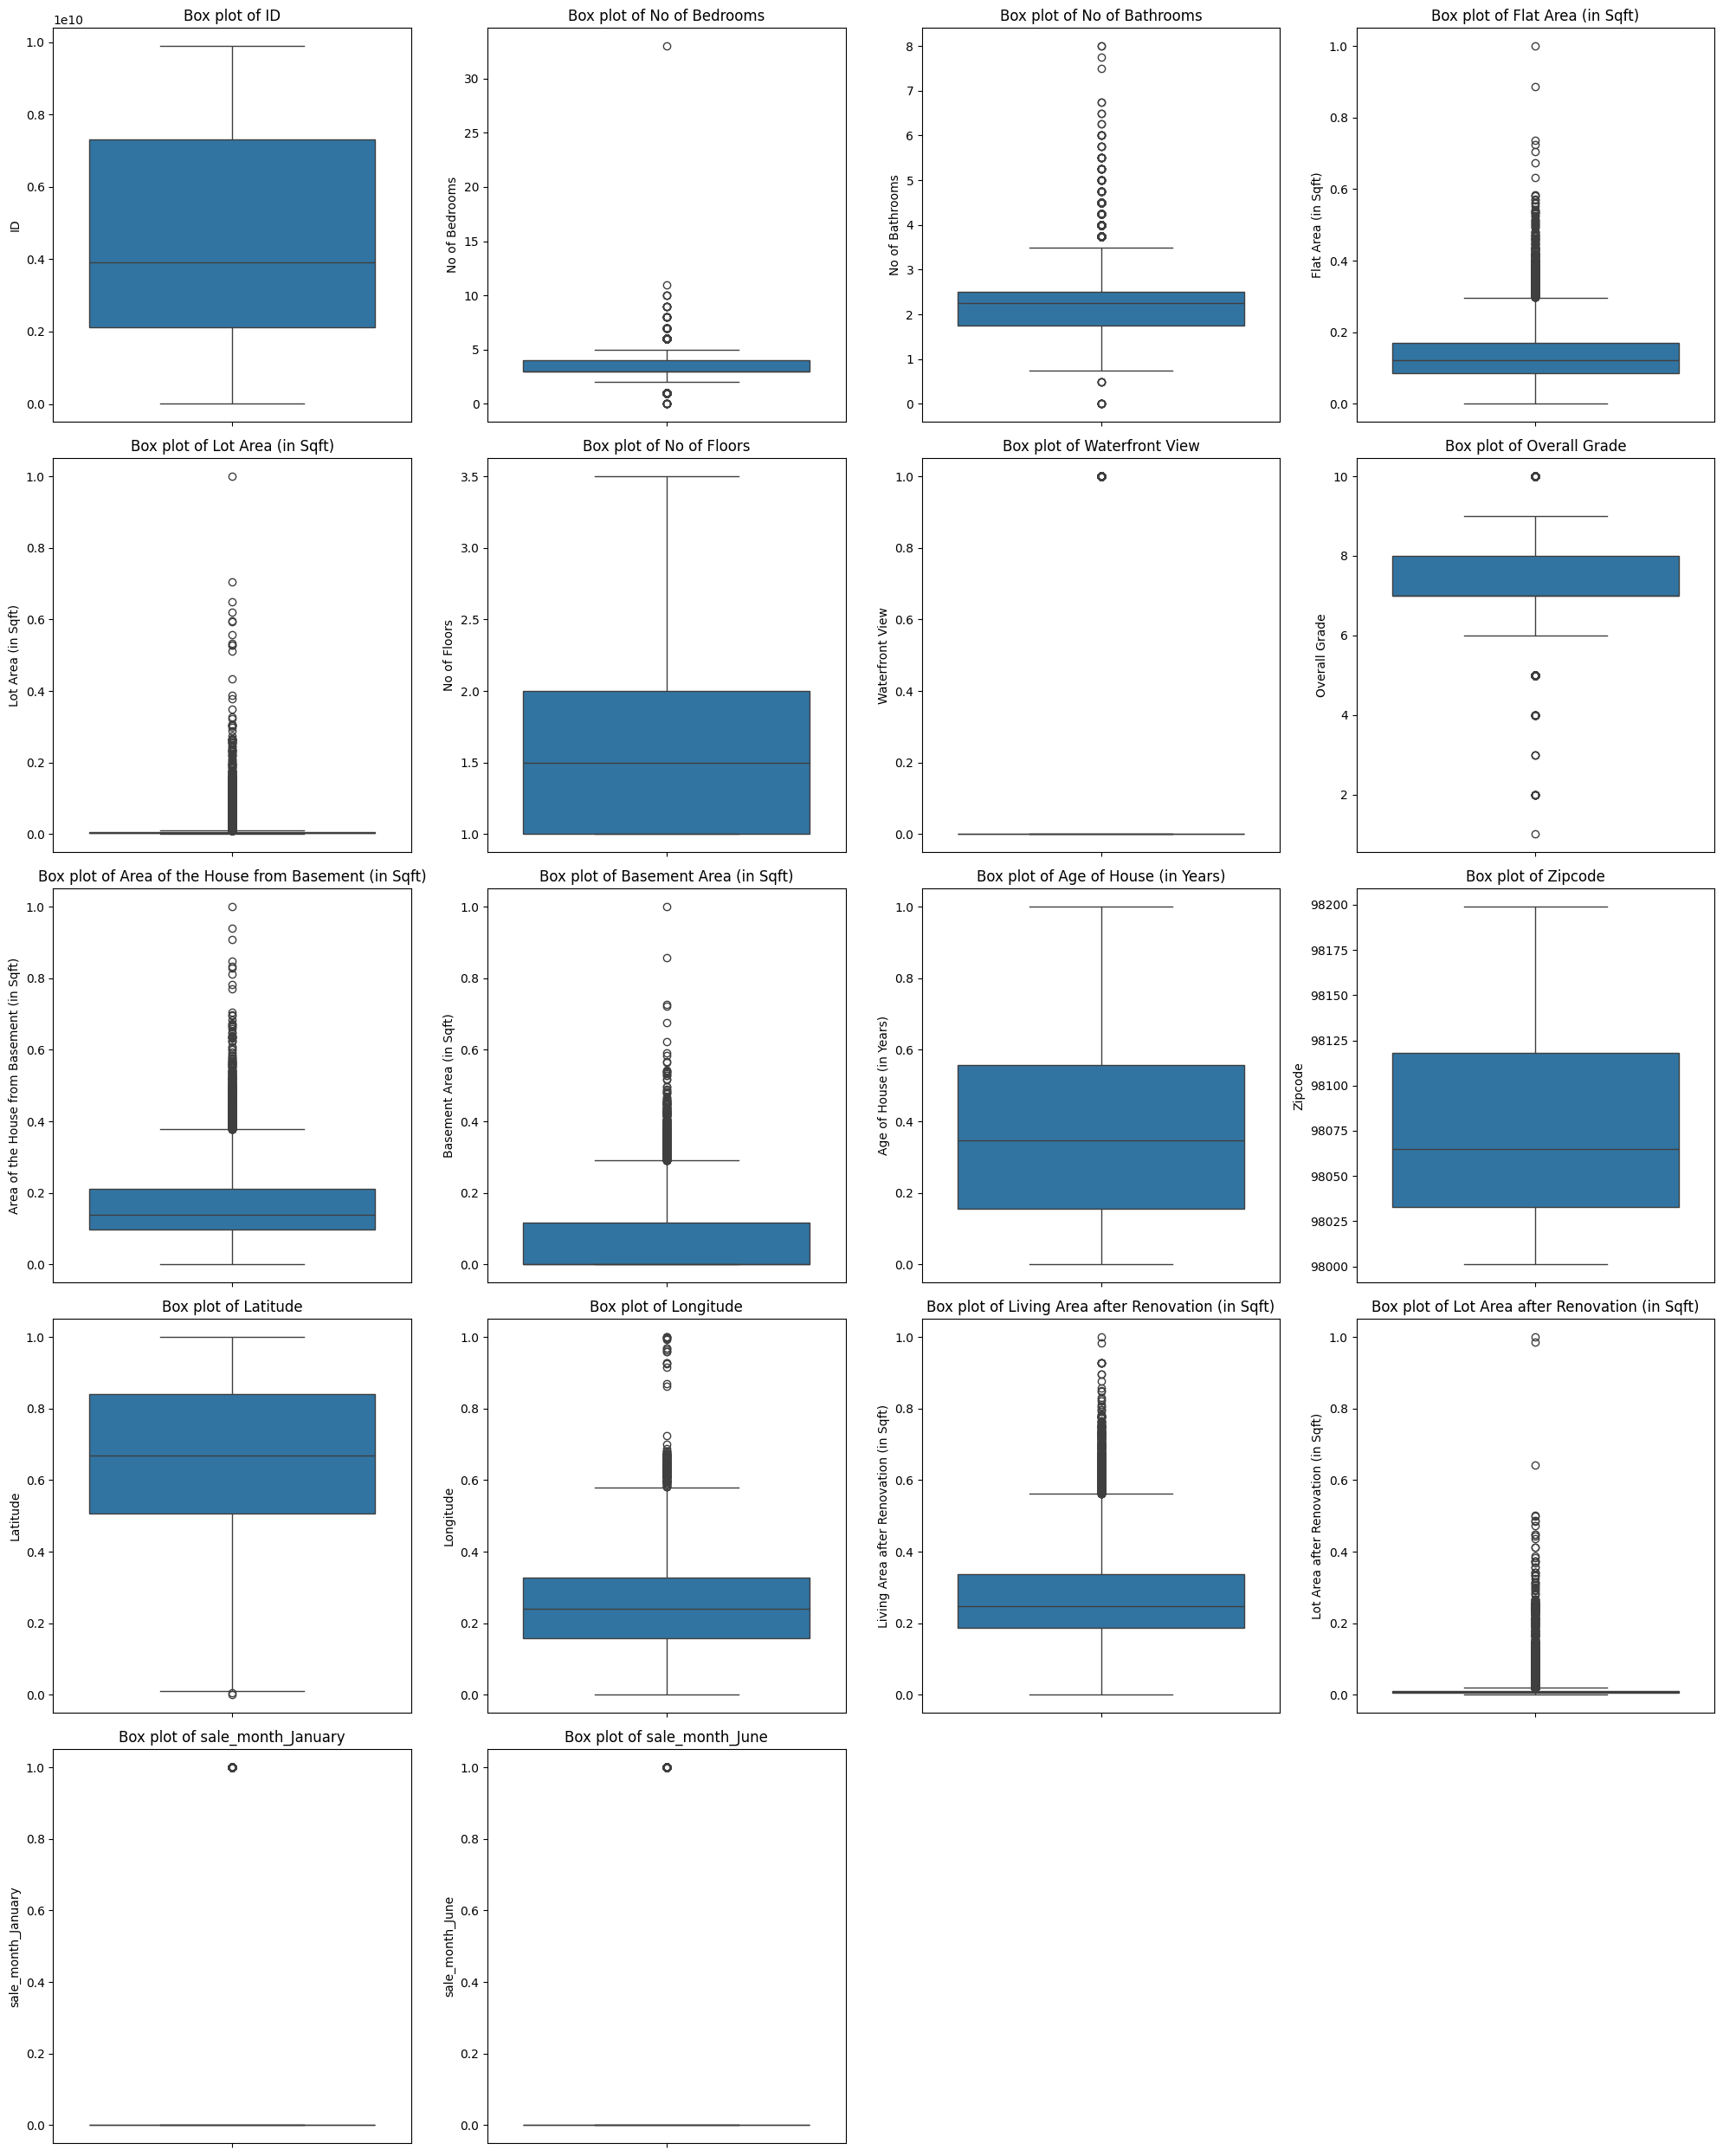

In [90]:
# Boxplot before handling outlier

plt.figure(figsize=(20, 25))

for i, column in enumerate(X.columns):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=X[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [91]:
# Handling outliers

def clip_outliers_iqr(column):
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X[column] = np.clip(X[column], lower_bound, upper_bound)
    return X

# Apply outlier clipping to all columns in X
for column in X.columns:
    X = clip_outliers_iqr(column)

print(f"Shape of X after outlier clipping: {X.shape}")
X.head()

Shape of X after outlier clipping: (21605, 18)


,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),sale_month_January,sale_month_June
0,7129300520,3.0,1.00,0.067170,0.003108,1.0,0,7.0,0.097588,0.000000,0.521739,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,0.0
1,6414100192,3.0,2.25,0.172075,0.004072,2.0,0,7.0,0.206140,0.082988,0.556522,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,0.0
2,5631500400,2.0,1.00,0.036226,0.005743,1.0,0,6.0,0.052632,0.000000,0.713043,98028.0,0.936143,0.237542,0.399415,0.008513,0.0,0.0
3,2487200875,4.0,3.00,0.126038,0.002714,1.0,0,7.0,0.083333,0.188797,0.434783,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,0.0
4,1954400510,3.0,2.00,0.104906,0.004579,1.0,0,8.0,0.152412,0.000000,0.243478,98074.0,0.741354,0.393688,0.241094,0.007871,0.0,0.0


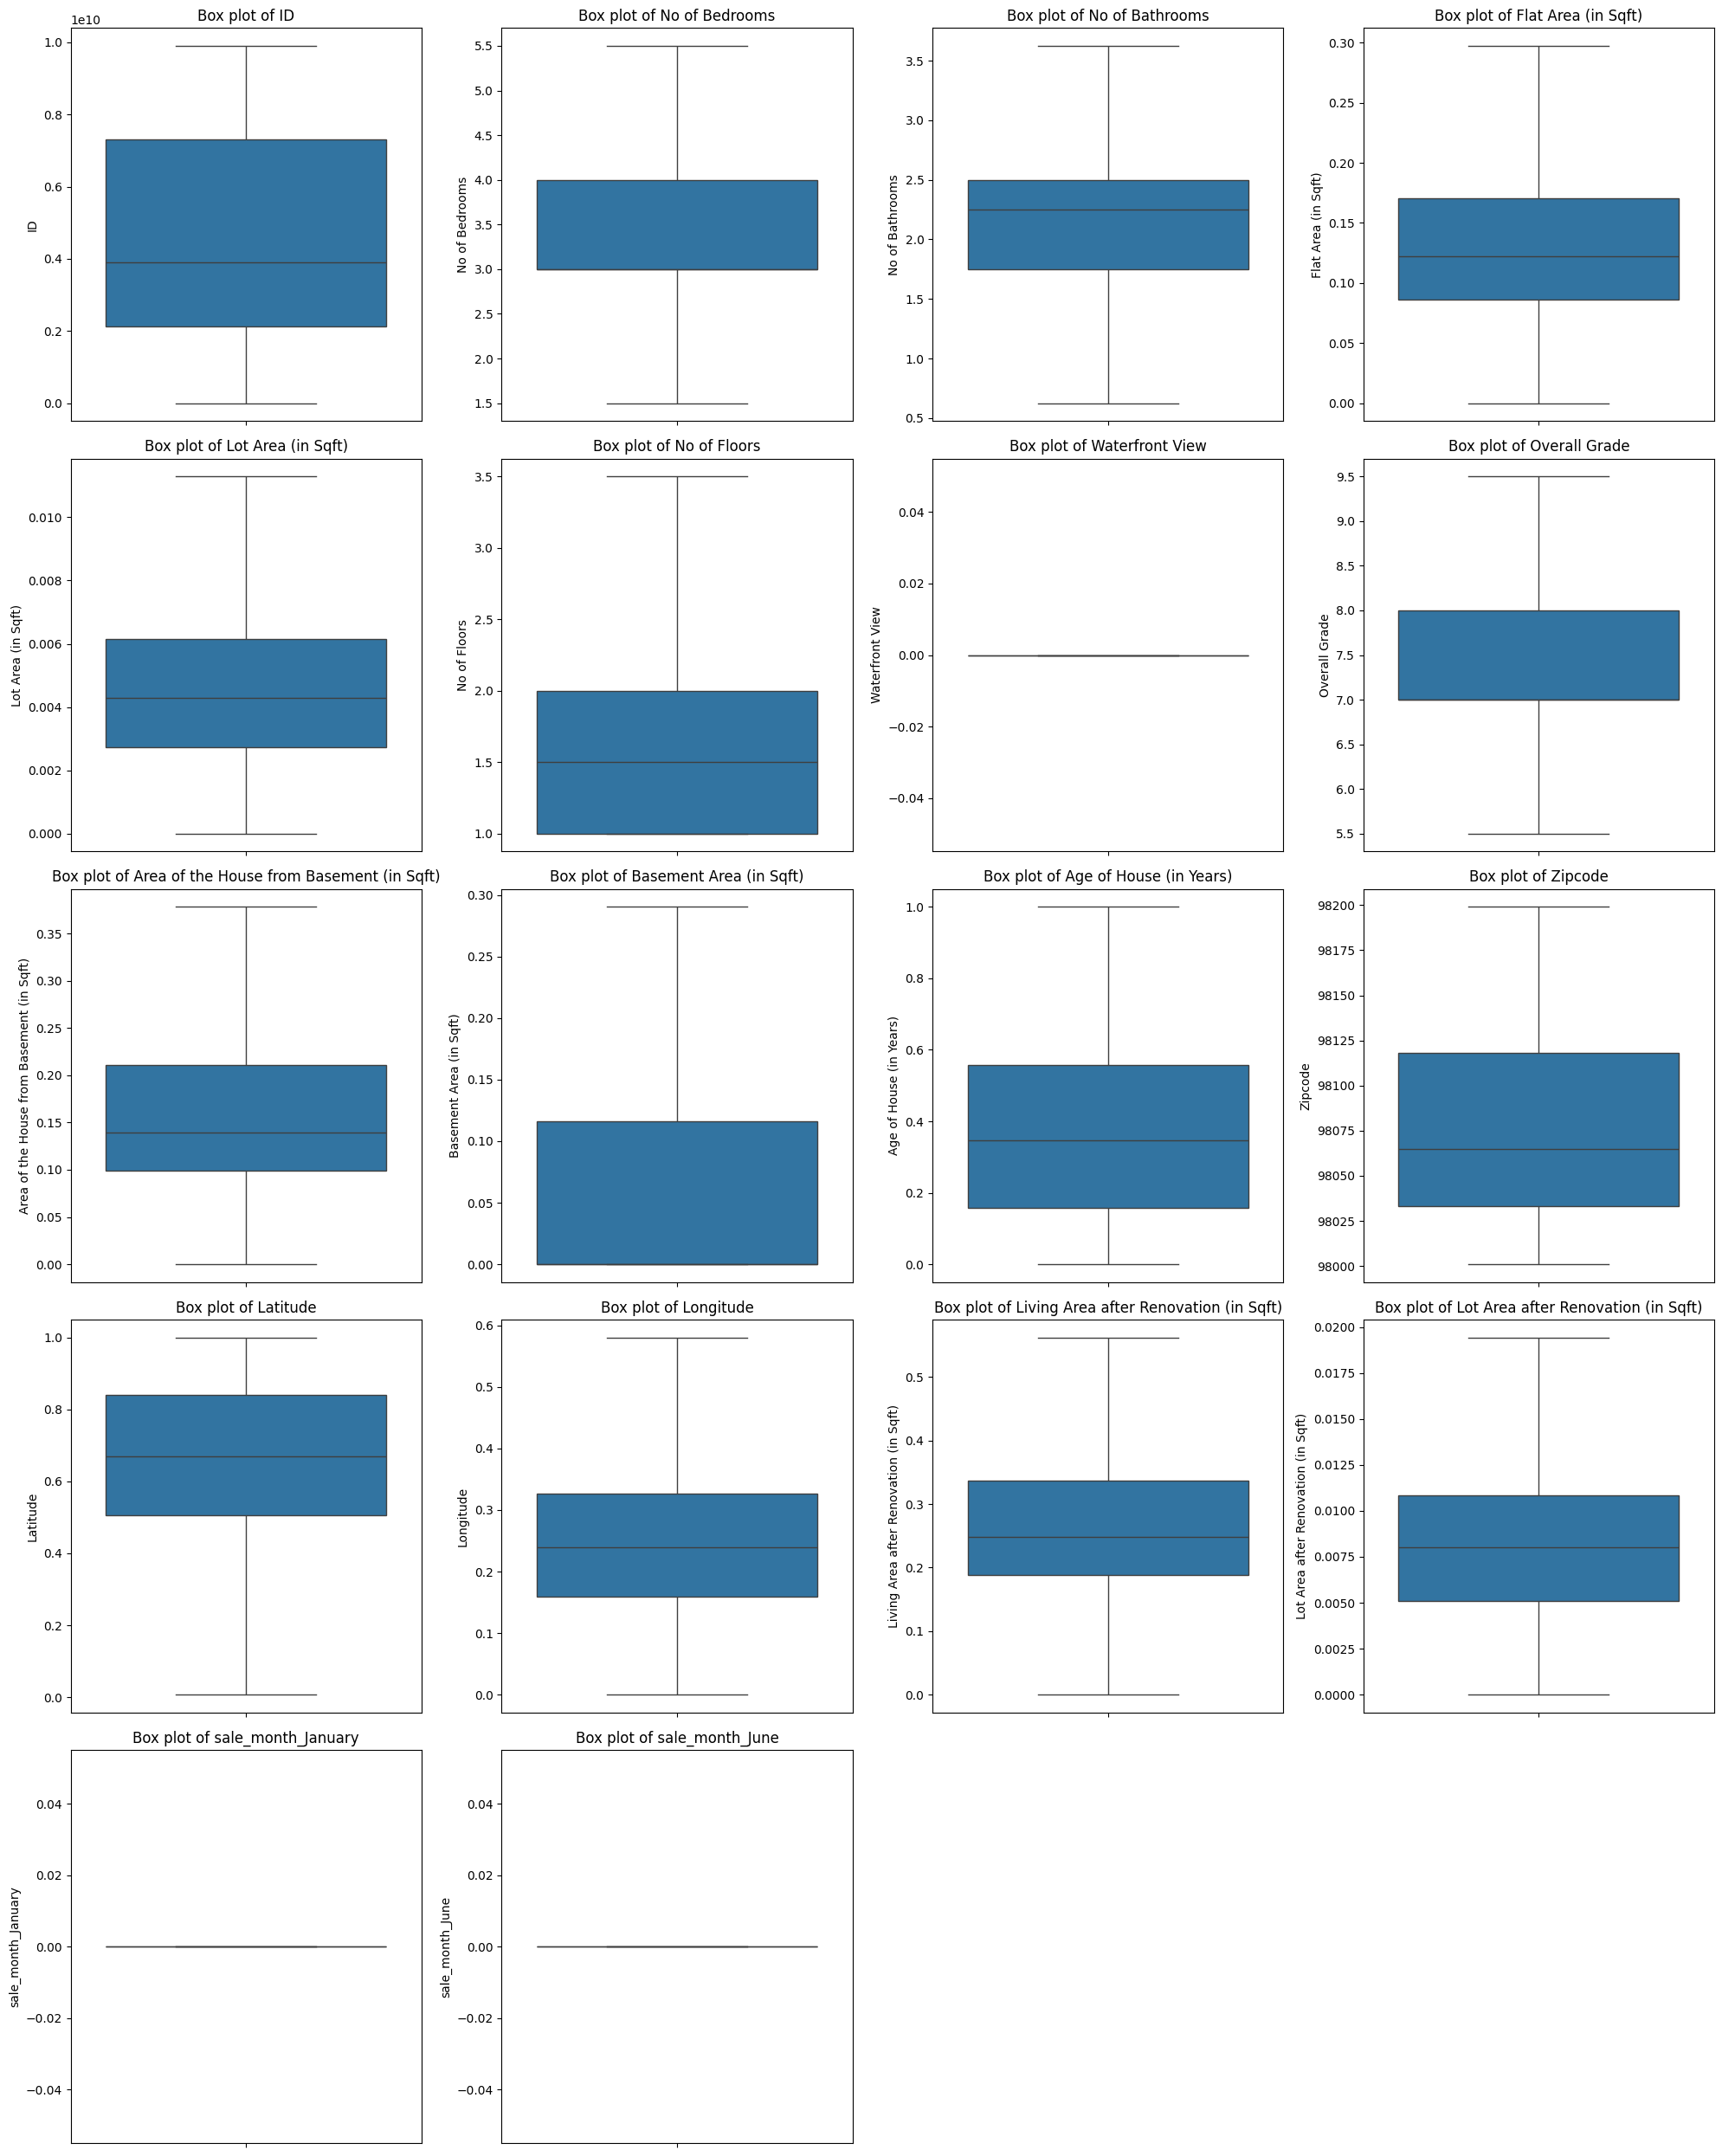

In [92]:
# Boxplot after outlier handling

plt.figure(figsize=(20, 25))

for i, column in enumerate(X.columns):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=X[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

#Train Test Split

In [93]:
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state  = 42)   # Here 20% data is used for testing and remaining 80% used for training.